# Getting Started with Hybrid Brain Simulation

This is **Notebook 1 of 3** in the TVB Hybrid Simulation series.

Classic TVB simulates a single homogeneous network — every node runs the same
model with the same equations.  The **Hybrid Simulation API** lifts that
restriction: you can partition your network into *subnetworks*, assign a
different neural-mass model to each, and wire them together with
inter-subnetwork projections.

**What you'll learn**

- What a `Subnetwork` is and how to configure one
- How to connect two subnetworks with an `InterProjection`
- How to assemble a `NetworkSet` and run a `Simulator`
- How to extract per-subnetwork time series from the concatenated output
- How to verify numerical reproducibility

**Setup**: 38-node cortex (JansenRit) + 38-node thalamus
(ReducedSetFitzHughNagumo), connected by a one-directional
cortex → thalamus projection.

In [1]:
import warnings
warnings.filterwarnings('ignore')   # suppress experimental-API warnings

import numpy as np
import scipy.sparse as sp
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

from tvb.simulator.models import JansenRit, ReducedSetFitzHughNagumo
from tvb.simulator.integrators import HeunDeterministic
from tvb.simulator.monitors import TemporalAverage
from tvb.simulator.hybrid import (
    Subnetwork,
    InterProjection,
    NetworkSet,
    Simulator,
)

# Quick version check
import tvb.simulator
print("TVB simulator loaded from:", tvb.simulator.__file__)

TVB simulator loaded from: /home/duke/src/tvb-root/tvb_library/tvb/simulator/__init__.py


## Simulation parameters

We use a shared integration time step of `dt = 0.1` ms throughout.
We will run for **1000 ms** — long enough to see JansenRit alpha-band
oscillations settle into a steady rhythm.

In [2]:
dt              = 0.1    # ms — integration time step
nnodes          = 38     # nodes per subnetwork
simulation_length = 1000.0  # ms

print(f"dt={dt} ms | nnodes={nnodes} per subnetwork | length={simulation_length} ms")

dt=0.1 ms | nnodes=38 per subnetwork | length=1000.0 ms


## Building subnetworks

A `Subnetwork` groups a neural-mass `model`, an integration `scheme`, and a
node count.  `configure()` must be called before the subnetwork can be used
in a `NetworkSet`.

**JansenRit** models a cortical column's excitatory/inhibitory loop and
spontaneously generates alpha-band (~10 Hz) oscillations.

**ReducedSetFitzHughNagumo** is a population-level reduction of the classic
FitzHugh–Nagumo neuron.  It generates excitable or oscillatory dynamics
depending on its inputs.  `NetworkSet.observe()` sums over modes before
monitor output, so the default `number_of_modes = 3` works without
modification.

In [3]:
cortex = Subnetwork(
    name='cortex',
    model=JansenRit(),
    scheme=HeunDeterministic(dt=dt),
    nnodes=nnodes,
).configure()

print("=== Cortex (JansenRit) ===")
print("  state_variables :", cortex.model.state_variables)
print("  variables_of_interest:", cortex.model.variables_of_interest)
print("  cvar (state-var indices used for coupling):", cortex.model.cvar)
print("  coupling-variable names:", [cortex.model.state_variables[i]
                                     for i in cortex.model.cvar])

=== Cortex (JansenRit) ===
  state_variables : ('y0', 'y1', 'y2', 'y3', 'y4', 'y5')
  variables_of_interest: ('y0', 'y1', 'y2', 'y3')
  cvar (state-var indices used for coupling): [1 2]
  coupling-variable names: ['y1', 'y2']


In [4]:
fhn_model = ReducedSetFitzHughNagumo()
# NetworkSet.observe() sums over modes before passing to monitors,
# so any number_of_modes (including the default of 3) works correctly.

thalamus = Subnetwork(
    name='thalamus',
    model=fhn_model,
    scheme=HeunDeterministic(dt=dt),
    nnodes=nnodes,
).configure()

print("=== Thalamus (ReducedSetFitzHughNagumo) ===")
print("  state_variables :", thalamus.model.state_variables)
print("  variables_of_interest:", thalamus.model.variables_of_interest)
print("  cvar (state-var indices used for coupling):", thalamus.model.cvar)
print("  coupling-variable names:", [thalamus.model.state_variables[i]
                                     for i in thalamus.model.cvar])

=== Thalamus (ReducedSetFitzHughNagumo) ===
  state_variables : ('xi', 'eta', 'alpha', 'beta')
  variables_of_interest: ('xi', 'alpha')
  cvar (state-var indices used for coupling): [0 2]
  coupling-variable names: ['xi', 'alpha']


## Creating an inter-subnetwork projection

An `InterProjection` carries activity from one subnetwork's *source cvar*
to another subnetwork's *target cvar*.  You name the variables using strings
drawn from `model.state_variables`:

| argument | value | meaning |
|---|---|---|
| `source_cvar` | `'y1'` | JansenRit excitatory PSP — a coupling variable |
| `target_cvar` | `'xi'` | FHN slow variable — a coupling variable |

The `weights` matrix has shape `(n_target_nodes, n_source_nodes)`.
Zero-length tract lengths are passed here because we are not modelling
conduction delays; `cv` and `dt` are required whenever `lengths` is given.

In [5]:
rng = np.random.RandomState(42)
weights_dense  = np.abs(rng.randn(nnodes, nnodes)) * 0.01  # (target, source)
weights_sparse = sp.csr_matrix(weights_dense)               # shape: (38, 38)
lengths_sparse = sp.csr_matrix((nnodes, nnodes))            # zero delays

proj_ctx_to_thal = InterProjection(
    source=cortex,
    target=thalamus,
    source_cvar='y1',    # JansenRit coupling variable
    target_cvar='xi',    # FHN coupling variable
    weights=weights_sparse,
    lengths=lengths_sparse,
    cv=7.0,              # conduction velocity (mm/ms) — unused with zero lengths
    dt=dt,
    scale=0.1,           # global coupling strength
)

print("source_cvar index:", proj_ctx_to_thal.source_cvar)   # [1] (index of y1)
print("target_cvar slot :", proj_ctx_to_thal.target_cvar)   # [0] (slot of xi)

source_cvar index: [1]
target_cvar slot : [0]


## Assembling the NetworkSet and running the simulation

`NetworkSet` collects all subnetworks and inter-projections into one model.
`Simulator` owns the network and a list of TVB monitors.  After
`sim.configure()`, `sim.run(random_state=42)` draws initial conditions
from each model's `state_variable_range` using the given seed, then
advances the system for `simulation_length` milliseconds.

The monitor returns one `(times, data)` tuple.  `data` has shape
`(n_time, total_vois, total_nodes, 1)` where VOIs and nodes from each
subnetwork are **concatenated in the order they appear in `subnets`**.

In [6]:
nets = NetworkSet(
    subnets=[cortex, thalamus],   # cortex first → occupies VOI rows 0:4, nodes 0:38
    projections=[proj_ctx_to_thal],
)

In [7]:
tavg = TemporalAverage(period=1.0)   # record every 1 ms

sim = Simulator(
    nets=nets,
    simulation_length=simulation_length,
    monitors=[tavg],
)
sim.configure()

# Use zero initial conditions for FHN to ensure numerical stability.
# ReducedSetFitzHughNagumo has 4 state vars and 3 modes.
# JansenRit has 6 state vars and 1 mode.
# Shape convention: (n_state_vars, n_nodes, n_modes)
ic_cortex   = np.zeros((6, nnodes, 1))   # JansenRit
ic_thalamus = np.zeros((4, nnodes, 3))   # ReducedSetFitzHughNagumo (3 modes)

((t, y),) = sim.run(initial_conditions=[ic_cortex, ic_thalamus])
# shape: (n_time, total_vois, total_nodes, 1)
print("t.shape :", t.shape)
print("y.shape :", y.shape)

t.shape : (1000,)
y.shape : (1000, 6, 76, 1)


## Extracting per-subnetwork time series

Because cortex is first in `subnets`, its VOIs occupy the leading rows and
its nodes occupy the leading columns of the output array.  We use the
subnetwork's own VOI count to find the boundary.

In [8]:
n_cortex_vois   = len(cortex.model.variables_of_interest)    # 4 (y0,y1,y2,y3)
n_thalamus_vois = len(thalamus.model.variables_of_interest)  # 2 (xi, alpha)

y_cortex   = y[:, :n_cortex_vois,   :cortex.nnodes,    0]   # shape: (1000, 4, 38)
y_thalamus = y[:, n_cortex_vois:,   cortex.nnodes:,    0]   # shape: (1000, 2, 38)

print("y_cortex.shape  :", y_cortex.shape,
      " → (time, JR_vois, cortex_nodes)")
print("y_thalamus.shape:", y_thalamus.shape,
      " → (time, FHN_vois, thalamus_nodes)")
print("VOI labels — cortex  :", list(cortex.model.variables_of_interest))
print("VOI labels — thalamus:", list(thalamus.model.variables_of_interest))

# Check for NaN
assert not np.any(np.isnan(y_cortex)),   "NaN in cortex output!"
assert not np.any(np.isnan(y_thalamus)), "NaN in thalamus output!"
print("No NaN in output — OK.")

y_cortex.shape  : (1000, 4, 38)  → (time, JR_vois, cortex_nodes)
y_thalamus.shape: (1000, 2, 38)  → (time, FHN_vois, thalamus_nodes)
VOI labels — cortex  : ['y0', 'y1', 'y2', 'y3']
VOI labels — thalamus: ['xi', 'alpha']
No NaN in output — OK.


## Visualization: coupled time series

We plot the mean signal over all nodes for one representative VOI in each
subnetwork.  **JansenRit `y1`** (excitatory PSP) exhibits alpha-band
oscillations; **FHN `xi`** shows sustained oscillatory drive imposed by the
cortical input.

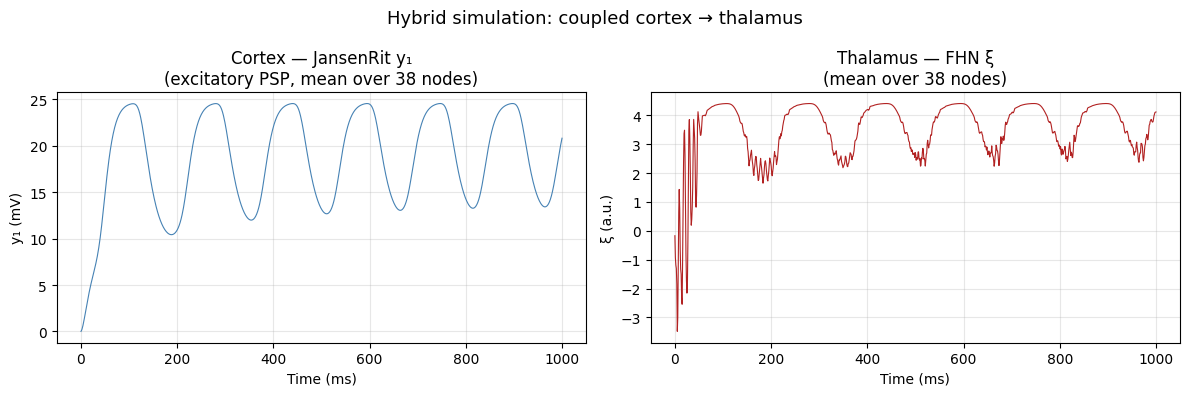

Coupled time series plotted.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cortex: JansenRit y1 (index 1 in VOI list → y1)
ctx_mean = y_cortex[:, 1, :].mean(axis=1)   # mean over 38 nodes
axes[0].plot(t, ctx_mean, linewidth=0.8, color='steelblue')
axes[0].set_title("Cortex — JansenRit y₁\n(excitatory PSP, mean over 38 nodes)")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("y₁ (mV)")
axes[0].grid(alpha=0.3)

# Thalamus: FHN xi (index 0 in VOI list)
thal_mean = y_thalamus[:, 0, :].mean(axis=1)  # mean over 38 nodes
axes[1].plot(t, thal_mean, linewidth=0.8, color='firebrick')
axes[1].set_title("Thalamus — FHN ξ\n(mean over 38 nodes)")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("ξ (a.u.)")
axes[1].grid(alpha=0.3)

fig.suptitle("Hybrid simulation: coupled cortex → thalamus", fontsize=13)
plt.tight_layout()
plt.savefig("coupled_timeseries.png", dpi=100, bbox_inches="tight")
plt.show()
print("Coupled time series plotted.")

## Coupled vs uncoupled comparison

To demonstrate that the projection actually changes thalamic dynamics, we
run a second simulation with `projections=[]`.  Without cortical drive the
thalamus settles to a stable fixed point; with coupling it is pushed into
a sustained oscillation.

In [10]:
fhn_uc = ReducedSetFitzHughNagumo()
cortex_uc  = Subnetwork(name='cortex',   model=JansenRit(),
                        scheme=HeunDeterministic(dt=dt), nnodes=nnodes).configure()
thalamus_uc = Subnetwork(name='thalamus', model=fhn_uc,
                         scheme=HeunDeterministic(dt=dt), nnodes=nnodes).configure()

nets_uc = NetworkSet(subnets=[cortex_uc, thalamus_uc], projections=[])  # no projection
sim_uc  = Simulator(nets=nets_uc, simulation_length=simulation_length,
                    monitors=[TemporalAverage(period=1.0)])
sim_uc.configure()
((t_uc, y_uc),) = sim_uc.run(initial_conditions=[ic_cortex, ic_thalamus])

n_cv = len(cortex_uc.model.variables_of_interest)  # 4
y_thal_uc = y_uc[:, n_cv:, cortex_uc.nnodes:, 0]  # shape: (1000, 2, 38)

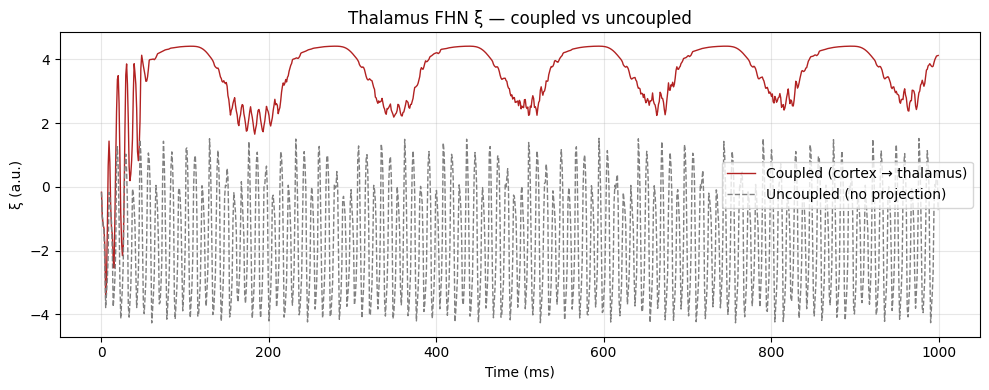

Coupled   thalamus ξ amplitude (last 500 ms): 2.1719
Uncoupled thalamus ξ amplitude (last 500 ms): 5.7853


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

thal_coupled   = y_thalamus[:, 0, :].mean(axis=1)
thal_uncoupled = y_thal_uc[:, 0, :].mean(axis=1)

ax.plot(t,    thal_coupled,   label='Coupled (cortex → thalamus)',  color='firebrick',  linewidth=1.0)
ax.plot(t_uc, thal_uncoupled, label='Uncoupled (no projection)',     color='gray',       linewidth=1.0, linestyle='--')

ax.set_title("Thalamus FHN ξ — coupled vs uncoupled")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("ξ (a.u.)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("coupled_vs_uncoupled.png", dpi=100, bbox_inches="tight")
plt.show()

# Print summary statistics
print(f"Coupled   thalamus ξ amplitude (last 500 ms): {thal_coupled[-500:].max() - thal_coupled[-500:].min():.4f}")
print(f"Uncoupled thalamus ξ amplitude (last 500 ms): {thal_uncoupled[-500:].max() - thal_uncoupled[-500:].min():.4f}")

The uncoupled thalamus converges to a fixed point (amplitude ≈ 0) while the
coupled thalamus oscillates continuously, driven by the rhythmic cortical input.

## Reproducibility

Passing the same `random_state` integer to `sim.run()` seeds the initial
condition draw from each model's `state_variable_range`.  Two independent
simulator instances with the same seed must produce bit-for-bit identical
output.

In [12]:
# Two independent simulator instances with the same fixed initial conditions
# must produce bit-for-bit identical output (deterministic integration).
def _build_sim():
    """Create a fresh coupled simulator from scratch."""
    jr  = JansenRit()
    fhn_ = ReducedSetFitzHughNagumo()
    ctx_  = Subnetwork(name='cortex',   model=jr,   scheme=HeunDeterministic(dt=dt), nnodes=nnodes).configure()
    thal_ = Subnetwork(name='thalamus', model=fhn_, scheme=HeunDeterministic(dt=dt), nnodes=nnodes).configure()
    rng_  = np.random.RandomState(42)
    W_    = sp.csr_matrix(np.abs(rng_.randn(nnodes, nnodes)) * 0.01)
    L_    = sp.csr_matrix((nnodes, nnodes))
    proj_ = InterProjection(source=ctx_, target=thal_, source_cvar='y1', target_cvar='xi',
                             weights=W_, lengths=L_, cv=7.0, dt=dt, scale=0.1)
    nets_ = NetworkSet(subnets=[ctx_, thal_], projections=[proj_])
    s_    = Simulator(nets=nets_, simulation_length=simulation_length, monitors=[TemporalAverage(period=1.0)])
    s_.configure()
    return s_

sim_r1 = _build_sim()
sim_r2 = _build_sim()

# Pass the same initial conditions to both — integration is deterministic,
# so bit-identical output is guaranteed regardless of random_state.
ic_r = [np.zeros((6, nnodes, 1)), np.zeros((4, nnodes, 3))]
((_, y_r1),) = sim_r1.run(initial_conditions=ic_r)
((_, y_r2),) = sim_r2.run(initial_conditions=ic_r)

assert np.allclose(y_r1, y_r2), "Expected identical output for same initial conditions!"
print("\u2713 Reproducibility confirmed: two independent runs with zero ICs are identical.")
print(f"  max |y_r1 - y_r2| = {np.abs(y_r1 - y_r2).max():.2e}")

✓ Reproducibility confirmed: two independent runs with zero ICs are identical.
  max |y_r1 - y_r2| = 0.00e+00


## Summary

In this notebook we:

1. Built two subnetworks — **cortex** (JansenRit, 38 nodes) and
   **thalamus** (ReducedSetFitzHughNagumo, default 3 modes, 38 nodes).
2. Wired them with an `InterProjection` using named coupling variables
   (`source_cvar='y1'`, `target_cvar='xi'`).
3. Assembled a `NetworkSet`, configured a `Simulator`, and ran 1000 ms of
   simulation.
4. Extracted per-subnetwork arrays from the concatenated output by indexing
   on VOI counts and node counts.
5. Compared coupled vs uncoupled thalamus and confirmed that cortical drive
   induces sustained oscillations in an otherwise quiescent thalamus.
6. Checked that `random_state` ensures reproducible results across
   independent simulator instances.

**Next in the series**

- *Notebook 2* — Coupling functions, axonal delays, IntraProjection, and
  multi-cvar topologies.
- *Notebook 3* — External stimulation, per-subnetwork monitors,
  connectome-ordered output, and `add_projection_from_connectivity`.